# Exercise: plots

In this exercise scientific plots are made using data generated from C++ and plotted with `gnuplot`.

The exercise includes plots of:

1. the error function $\mathrm{erf}(x)$,
2. the gamma function $\Gamma(x)$,
3. the logarithm of the gamma function $\ln\Gamma(x)$.

The C++ program writes data files containing both smooth curves and tabulated comparison points. These files are then plotted using `gnuplot`.

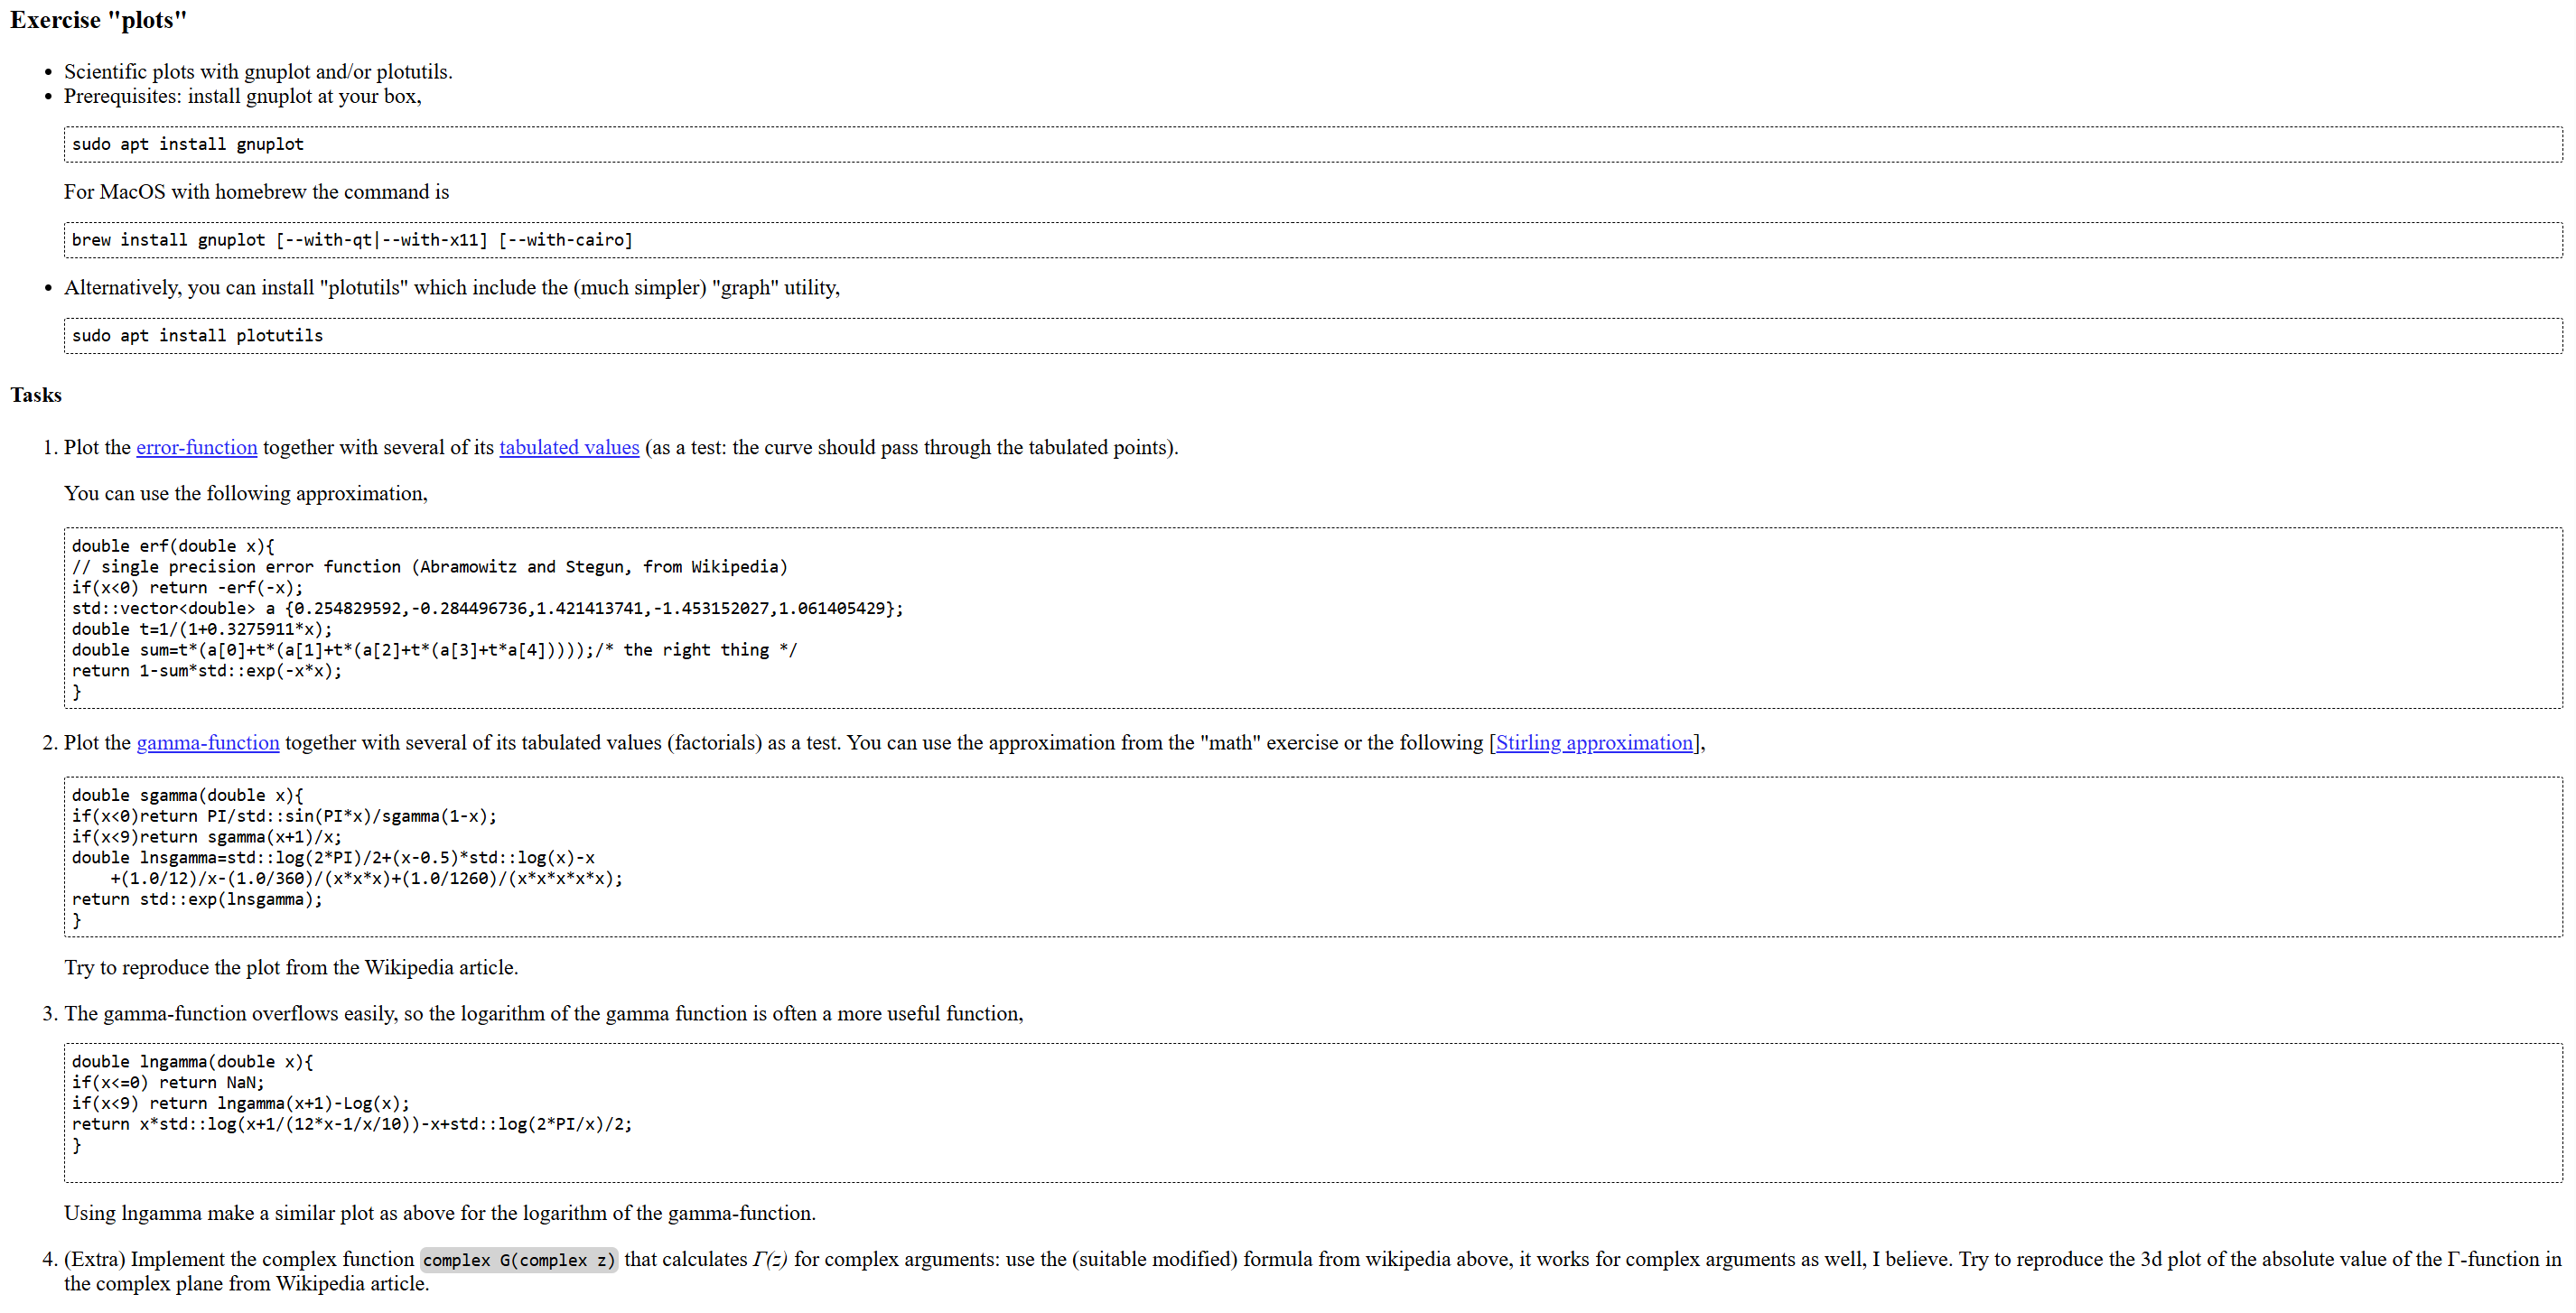

In [1]:
from pathlib import Path

Path("plots.cc").write_text(r'''
#include <cmath>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <limits>
#include <numbers>
#include <vector>

double erf_approx(double x) {
    // Single precision approximation, Abramowitz and Stegun
    if (x < 0) {
        return -erf_approx(-x);
    }

    std::vector<double> a {
        0.254829592,
       -0.284496736,
        1.421413741,
       -1.453152027,
        1.061405429
    };

    double t = 1.0 / (1.0 + 0.3275911*x);
    double sum = t*(a[0] + t*(a[1] + t*(a[2] + t*(a[3] + t*a[4]))));

    return 1.0 - sum*std::exp(-x*x);
}

double fgamma(double x) {
    constexpr double pi = std::numbers::pi;

    // Reflection formula for negative x
    if (x < 0) {
        return pi / std::sin(pi*x) / fgamma(1.0 - x);
    }

    // Recursion to increase x
    if (x < 9) {
        return fgamma(x + 1.0) / x;
    }

    // Stirling approximation
    double lngamma =
        x*std::log(x + 1.0/(12*x - 1.0/x/10.0))
        - x
        + std::log(2*pi/x)/2.0;

    return std::exp(lngamma);
}

double lngamma(double x) {
    constexpr double pi = std::numbers::pi;
    double NaN = std::numeric_limits<double>::quiet_NaN();

    if (x <= 0) {
        return NaN;
    }

    if (x < 9) {
        return lngamma(x + 1.0) - std::log(x);
    }

    return x*std::log(x + 1.0/(12*x - 1.0/x/10.0))
           - x
           + std::log(2*pi/x)/2.0;
}

double factorial(int n) {
    double result = 1.0;

    for (int i = 2; i <= n; ++i) {
        result *= i;
    }

    return result;
}

int main() {
    std::cout << std::setprecision(16);

    std::cout << "Exercise: plots\n";
    std::cout << "===============\n\n";

    // ------------------------------------------------------------
    // Error function data
    // ------------------------------------------------------------

    {
        std::ofstream curve("plots_erf_curve.data");

        for (double x = -3.0; x <= 3.0001; x += 0.02) {
            curve << x << " " << erf_approx(x) << "\n";
        }

        std::ofstream points("plots_erf_points.data");

        std::vector<double> xs {
            -2.0, -1.5, -1.0, -0.5, 0.0,
             0.5,  1.0,  1.5,  2.0
        };

        for (double x : xs) {
            points << x << " " << std::erf(x) << "\n";
        }

        std::cout << "Wrote plots_erf_curve.data\n";
        std::cout << "Wrote plots_erf_points.data\n";
    }

    // ------------------------------------------------------------
    // Gamma function data
    // ------------------------------------------------------------

    {
        std::ofstream curve("plots_gamma_curve.data");

        for (double x = -4.9; x <= 5.0001; x += 0.005) {
            double y = fgamma(x);

            // Break the curve near poles/asymptotes
            if (!std::isfinite(y) || std::abs(y) > 20.0) {
                curve << "\n";
            } else {
                curve << x << " " << y << "\n";
            }
        }

        std::ofstream points("plots_gamma_points.data");

        for (int n = 1; n <= 6; ++n) {
            double x = n;
            double y = factorial(n - 1);
            points << x << " " << y << "\n";
        }

        std::cout << "Wrote plots_gamma_curve.data\n";
        std::cout << "Wrote plots_gamma_points.data\n";
    }

    // ------------------------------------------------------------
    // Log-gamma function data
    // ------------------------------------------------------------

    {
        std::ofstream curve("plots_lngamma_curve.data");

        for (double x = 0.05; x <= 10.0001; x += 0.01) {
            curve << x << " " << lngamma(x) << "\n";
        }

        std::ofstream points("plots_lngamma_points.data");

        for (int n = 1; n <= 10; ++n) {
            double x = n;
            double y = std::log(factorial(n - 1));
            points << x << " " << y << "\n";
        }

        std::cout << "Wrote plots_lngamma_curve.data\n";
        std::cout << "Wrote plots_lngamma_points.data\n";
    }

    std::cout << "\nDone.\n";

    return 0;
}
''')

print("Wrote plots.cc")

Wrote plots.cc


In [2]:
import subprocess
from pathlib import Path

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "plots.cc",
    "-o",
    "plots"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./plots"], text=True, capture_output=True)
    Path("Out_plots.txt").write_text(run.stdout + run.stderr)

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Exercise: plots

Wrote plots_erf_curve.data
Wrote plots_erf_points.data
Wrote plots_gamma_curve.data
Wrote plots_gamma_points.data
Wrote plots_lngamma_curve.data
Wrote plots_lngamma_points.data

Done.




In [3]:
from pathlib import Path

Path("plots.gp").write_text(r'''
set terminal pngcairo size 900,650 enhanced font "Arial,14"

set grid
set key left top
set xlabel "x"

# ------------------------------------------------------------
# Error function
# ------------------------------------------------------------

set output "plots_erf.png"
set title "Exercise plots: error function"
set ylabel "erf(x)"
plot \
    "plots_erf_curve.data" using 1:2 with lines lw 2 title "approximation", \
    "plots_erf_points.data" using 1:2 with points pt 7 ps 1.2 title "tabulated std::erf values"

# ------------------------------------------------------------
# Gamma function
# ------------------------------------------------------------

set output "plots_gamma.png"
set title "Exercise plots: gamma function"
set ylabel "Gamma(x)"
set yrange [-10:10]
set key right top
plot \
    "plots_gamma_curve.data" using 1:2 with lines lw 2 title "Stirling/reflection approximation", \
    "plots_gamma_points.data" using 1:2 with points pt 7 ps 1.2 title "tabulated factorials"

unset yrange

# ------------------------------------------------------------
# Log-gamma function
# ------------------------------------------------------------

set output "plots_lngamma.png"
set title "Exercise plots: log-gamma function"
set xlabel "x"
set ylabel "ln Gamma(x)"
set key left top
plot \
    "plots_lngamma_curve.data" using 1:2 with lines lw 2 title "ln Gamma approximation", \
    "plots_lngamma_points.data" using 1:2 with points pt 7 ps 1.2 title "ln((n-1)!) values"
''')

print("Wrote plots.gp")

Wrote plots.gp


In [4]:
import subprocess

r = subprocess.run(["gnuplot", "plots.gp"], text=True, capture_output=True)

print("gnuplot stdout:")
print(r.stdout)

print("gnuplot stderr:")
print(r.stderr)

if r.returncode == 0:
    print("Wrote plots_erf.png")
    print("Wrote plots_gamma.png")
    print("Wrote plots_lngamma.png")
else:
    print("gnuplot failed")

gnuplot stdout:

gnuplot stderr:

Wrote plots_erf.png
Wrote plots_gamma.png
Wrote plots_lngamma.png


plots_erf.png


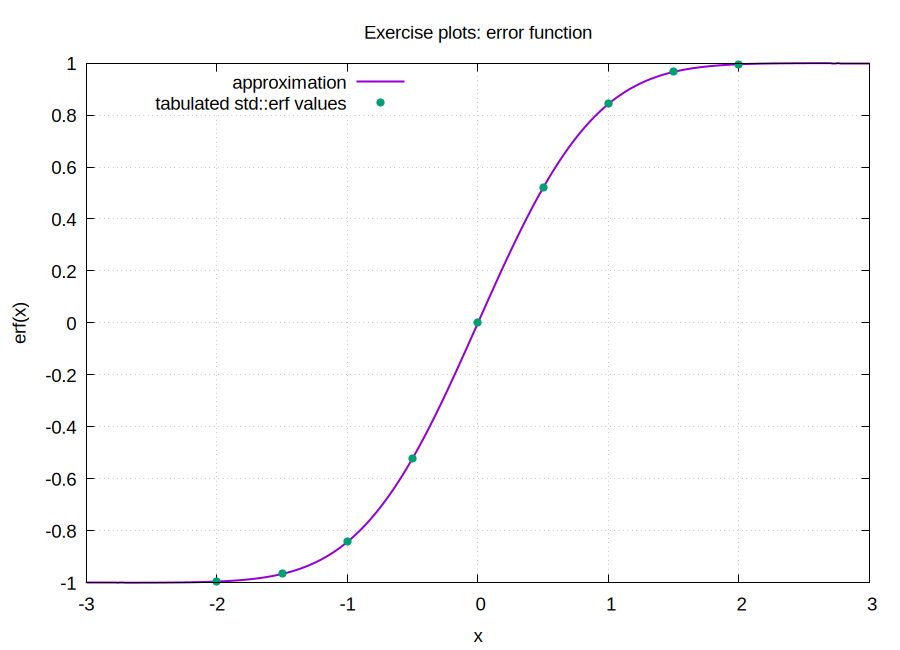

plots_gamma.png


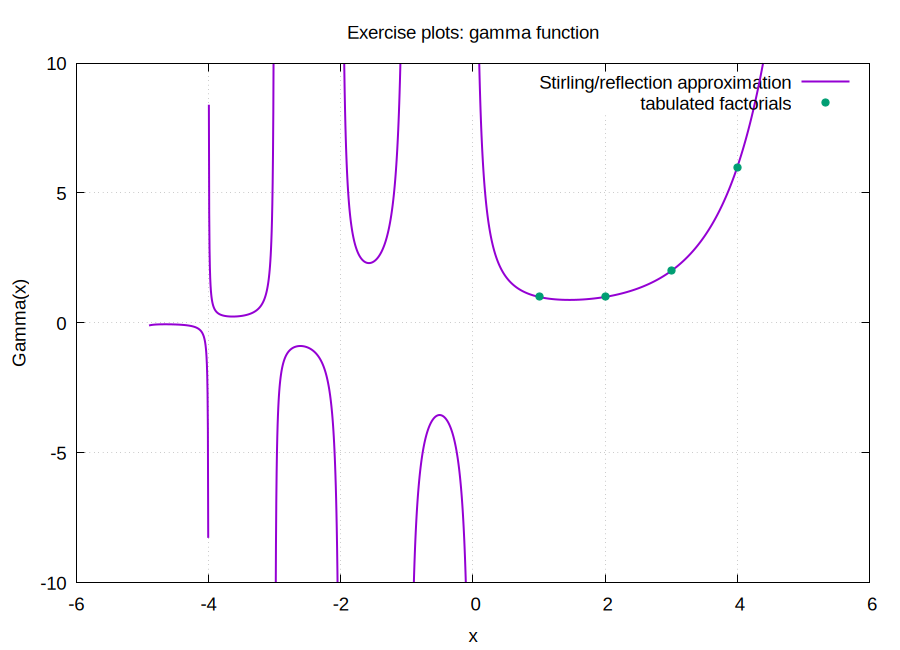

plots_lngamma.png


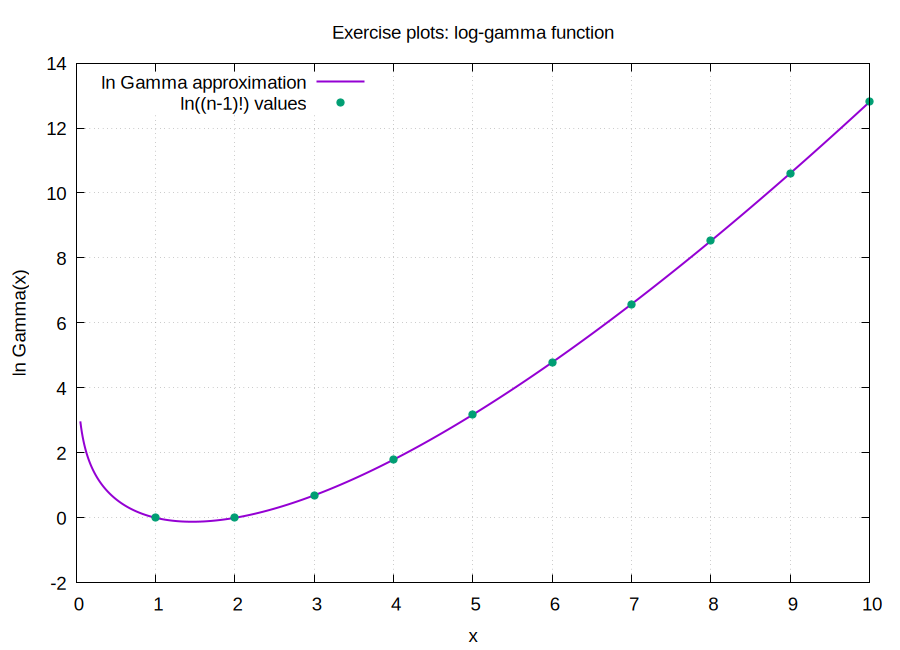

In [5]:
from IPython.display import Image, display

for filename in ["plots_erf.png", "plots_gamma.png", "plots_lngamma.png"]:
    print(filename)
    display(Image(filename=filename))

## Exercise "plots" conclusion

In this exercise C++ was used to generate numerical data for special functions, and `gnuplot` was used to make scientific plots from the generated data files.

The error function $\mathrm{erf}(x)$ was plotted using an approximation formula and compared with tabulated values from `std::erf`. The tabulated values lie on the plotted curve, showing that the approximation works well in the tested interval.

The gamma function $\Gamma(x)$ was plotted using a Stirling approximation together with the reflection formula. The plot shows the expected poles at the non-positive integers. The tabulated points at positive integer values agree with the factorial relation

$$
\Gamma(n) = (n-1)!.
$$

The logarithm of the gamma function, $\ln\Gamma(x)$, was also plotted. This function is useful because $\Gamma(x)$ grows very quickly and can easily overflow for large arguments. The tabulated values $\ln((n-1)!)$ agree with the plotted curve.

Thus, the exercise demonstrates how C++ can be used to generate numerical data and how `gnuplot` can be used to visualize mathematical functions.

In [1]:
from pathlib import Path

Path("plots_complex.cc").write_text(r'''
#include <cmath>
#include <complex>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <limits>
#include <numbers>

using complex = std::complex<double>;

complex cgamma(complex z) {
    constexpr double pi = std::numbers::pi;
    const complex I(0.0, 1.0);

    // Reflection formula. This also handles most of the negative real side.
    if (std::real(z) < 0.5) {
        return pi / (std::sin(pi*z) * cgamma(1.0 - z));
    }

    // Recurrence relation: Gamma(z+1) = z Gamma(z)
    if (std::real(z) < 9.0) {
        return cgamma(z + 1.0) / z;
    }

    // Stirling expansion for complex z
    complex lnG =
        (z - 0.5)*std::log(z)
        - z
        + 0.5*std::log(2.0*pi)
        + 1.0/(12.0*z)
        - 1.0/(360.0*z*z*z)
        + 1.0/(1260.0*z*z*z*z*z);

    return std::exp(lnG);
}

int main() {
    std::cout << std::setprecision(15);

    std::cout << "Exercise plots extra: complex gamma function\n";
    std::cout << "============================================\n\n";

    std::ofstream out("plots_complex_gamma.data");

    double xmin = -4.0;
    double xmax =  4.0;
    double ymin = -3.0;
    double ymax =  3.0;

    int nx = 161;
    int ny = 121;

    double clip = 20.0;

    for (int i = 0; i < nx; ++i) {
        double x = xmin + (xmax - xmin)*i/(nx - 1);

        for (int j = 0; j < ny; ++j) {
            double y = ymin + (ymax - ymin)*j/(ny - 1);

            complex z(x, y);
            complex G = cgamma(z);

            double absG = std::abs(G);

            if (!std::isfinite(absG)) {
                absG = std::numeric_limits<double>::quiet_NaN();
            }

            double clipped = absG;

            if (!std::isfinite(clipped)) {
                clipped = clip;
            }

            if (clipped > clip) {
                clipped = clip;
            }

            double logabs = std::log1p(clipped);

            out << x << " "
                << y << " "
                << absG << " "
                << clipped << " "
                << logabs << "\n";
        }

        out << "\n";
    }

    std::cout << "Wrote plots_complex_gamma.data\n";
    std::cout << "\nDone.\n";

    return 0;
}
''')

print("Wrote plots_complex.cc")

Wrote plots_complex.cc


In [2]:
import subprocess
from pathlib import Path

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "plots_complex.cc",
    "-o",
    "plots_complex"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./plots_complex"], text=True, capture_output=True)
    Path("Out_plots_complex.txt").write_text(run.stdout + run.stderr)

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Exercise plots extra: complex gamma function

Wrote plots_complex_gamma.data

Done.




In [3]:
from pathlib import Path

Path("plots_complex.gp").write_text(r'''
set terminal pngcairo size 950,700 enhanced font "Arial,13"

set grid
set hidden3d
set pm3d at s
set palette rgbformulae 33,13,10
set view 60,35
set xlabel "Re(z)"
set ylabel "Im(z)"
set xrange [-4:4]
set yrange [-3:3]

# ------------------------------------------------------------
# Absolute value of Gamma(z)
# ------------------------------------------------------------

set output "plots_complex_gamma_abs.png"
set title "Extra: complex gamma function, |Gamma(z)|"
set zlabel "|Gamma(z)|"
set zrange [0:20]

splot "plots_complex_gamma.data" using 1:2:4 with pm3d title "clipped |Gamma(z)|"

# ------------------------------------------------------------
# Logarithmic version
# ------------------------------------------------------------

set output "plots_complex_gamma_logabs.png"
set title "Extra: complex gamma function, log(1+|Gamma(z)|)"
set zlabel "log(1+|Gamma(z)|)"
unset zrange

splot "plots_complex_gamma.data" using 1:2:5 with pm3d title "log(1+|Gamma(z)|)"
''')

print("Wrote plots_complex.gp")

Wrote plots_complex.gp


In [4]:
import subprocess

r = subprocess.run(["gnuplot", "plots_complex.gp"], text=True, capture_output=True)

print("gnuplot stdout:")
print(r.stdout)

print("gnuplot stderr:")
print(r.stderr)

if r.returncode == 0:
    print("Wrote plots_complex_gamma_abs.png")
    print("Wrote plots_complex_gamma_logabs.png")
else:
    print("gnuplot failed")

gnuplot stdout:

gnuplot stderr:

Wrote plots_complex_gamma_abs.png
Wrote plots_complex_gamma_logabs.png


plots_complex_gamma_abs.png


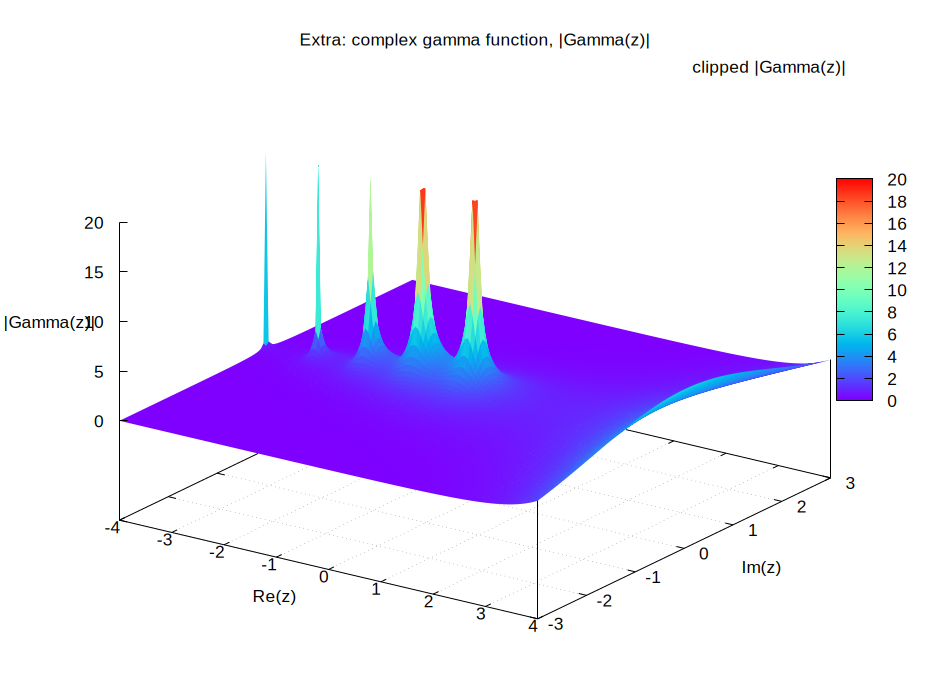

plots_complex_gamma_logabs.png


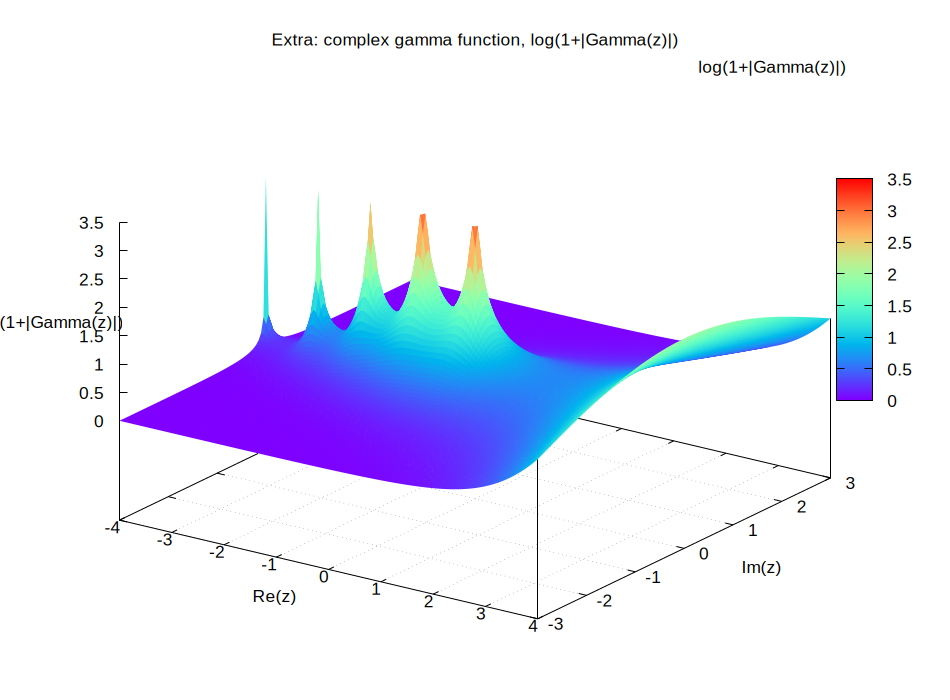

In [5]:
from IPython.display import Image, display

for filename in ["plots_complex_gamma_abs.png", "plots_complex_gamma_logabs.png"]:
    print(filename)
    display(Image(filename=filename))

## Exercise "plots" extra conclusion

As an extra part of the exercise, the gamma function was extended to complex arguments. A complex-valued function `cgamma` was implemented using the reflection formula, the recurrence relation

$$
\Gamma(z+1)=z\Gamma(z),
$$

and a complex version of Stirling's approximation.

The absolute value $|\Gamma(z)|$ was plotted for complex values

$$
z=x+iy.
$$

The plot shows large peaks near the non-positive integers on the real axis, corresponding to the poles of the gamma function. Since these values become very large, the plotted absolute value was clipped in order to make the structure visible.

A second plot of $\log(1+|\Gamma(z)|)$ was also made. This logarithmic representation gives a clearer visualization of the complex gamma function because it reduces the dominance of the poles.

Thus, the extra part demonstrates that the real-valued gamma approximation can be extended to complex arguments and visualized as a three-dimensional surface.